# Huấn luyện mô hình Text Classification với LSTM

Notebook này tiếp tục phần pipeline xử lý văn bản và huấn luyện mô hình Recurrent Neural Network (LSTM/BiLSTM) để phân loại 20 chủ đề tin tức (20 Newsgroups).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

import nltk
from nltk.corpus import stopwords
# Tải stopwords (Chỉ cần chạy lần đầu)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2026-03-22 14:57:00.963900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774191421.370214      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774191421.484151      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774191422.484347      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774191422.484405      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid lin

## 1. Tải và Tiền xử lý Dữ liệu

In [2]:
# Tải dữ liệu
print("Tải dữ liệu 20 Newsgroups...")
train_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test_data = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 1]
    return ' '.join(words)

print("Đang tiền xử lý (loại bỏ stopwords, punctuation)...")
X_train = [clean_text(doc) for doc in train_data.data]
X_test = [clean_text(doc) for doc in test_data.data]

y_train = train_data.target
y_test = test_data.target

labels_names = train_data.target_names
num_classes = len(labels_names)
print(f"Số lượng class: {num_classes}")


Tải dữ liệu 20 Newsgroups...
Đang tiền xử lý (loại bỏ stopwords, punctuation)...
Số lượng class: 20


## 2. Tokenization & Padding
Chuyển đổi text thành các chuỗi số nguyên (sequences) để đưa vào màng Embedding của LSTM.

In [3]:
# Các siêu tham số (Hyperparameters)
MAX_VOCAB_SIZE = 30000 
MAX_SEQUENCE_LENGTH = 300 
EMBEDDING_DIM = 100 

# =========================================================
# Tải GloVe 100d (Chạy trên Kaggle hoặc Google Colab)
# Bỏ qua nếu đã tải hoặc add Dataset GloVe từ Kaggle.
# =========================================================
import os, urllib.request, zipfile
glove_file = 'glove.6B.100d.txt'
if not os.path.exists(glove_file):
    print("Đang tải GloVe embeddings...")
    urllib.request.urlretrieve('http://nlp.stanford.edu/data/glove.6B.zip', 'glove.6B.zip')
    print("Giải nén GloVe embeddings...")
    with zipfile.ZipFile('glove.6B.zip', 'r') as zip_ref:
        zip_ref.extractall()
    print("Xong!")

print("Đang tải siêu ma trận GloVe vào memory...")
embeddings_index = {}
with open(glove_file, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
print(f"Số lượng từ trong GloVe: {len(embeddings_index)}")

# Khởi tạo Tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Chuyển text thành chuỗi số
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding/Truncating
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"Hình dạng của X_train_pad: {X_train_pad.shape}")
print(f"Hình dạng của X_test_pad: {X_test_pad.shape}")

word_index = tokenizer.word_index
vocab_size = min(MAX_VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, i in word_index.items():
    if i >= MAX_VOCAB_SIZE:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
print(f"Kích thước embedding matrix: {embedding_matrix.shape}")


Đang tải GloVe embeddings...
Giải nén GloVe embeddings...
Xong!
Đang tải siêu ma trận GloVe vào memory...
Số lượng từ trong GloVe: 400000
Hình dạng của X_train_pad: (11314, 300)
Hình dạng của X_test_pad: (7532, 300)
Kích thước embedding matrix: (30000, 100)


## 3. Xây dựng Mô hình LSTM

Sử dụng mạng LSTM 2 chiều (Bidirectional LSTM) để học tri thức về ngữ cảnh của văn bản từ cả hai phía (trái sang phải và phải sang trái).

In [4]:
from tensorflow.keras.initializers import Constant

model = Sequential([
    Embedding(
        input_dim=vocab_size, 
        output_dim=EMBEDDING_DIM, 
        embeddings_initializer=Constant(embedding_matrix),
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=False
    ),
    SpatialDropout1D(0.2),
    # Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(128)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1774191656.118208      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774191656.124515      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Huấn luyện (Training)

In [5]:
EPOCHS = 30
BATCH_SIZE = 64

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad, 
    y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
    validation_split=0.1,  # Tách 10% dữ liệu train ra làm tập validation
    callbacks=[early_stopping]
)

Epoch 1/30


I0000 00:00:1774191662.983885     122 cuda_dnn.cc:529] Loaded cuDNN version 91002


160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.1433 - loss: 2.7174 - val_accuracy: 0.3578 - val_loss: 1.9433
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.3275 - loss: 1.9818 - val_accuracy: 0.3710 - val_loss: 1.9122
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.3991 - loss: 1.7840 - val_accuracy: 0.4611 - val_loss: 1.5996
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.4478 - loss: 1.6500 - val_accuracy: 0.4505 - val_loss: 1.6414
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.4991 - loss: 1.5154 - val_accuracy: 0.5168 - val_loss: 1.4453
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5246 - loss: 1.4305 - val_accuracy: 0.5459 - val_loss: 1.3576
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5453 - loss: 1.3799 - val_accuracy: 0.5512 - val_loss: 1.3310
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5586 - loss: 1.3343 - val_accuracy: 0.55

## 5. Đánh giá kết quả mô hình (Evaluation & Plotting)

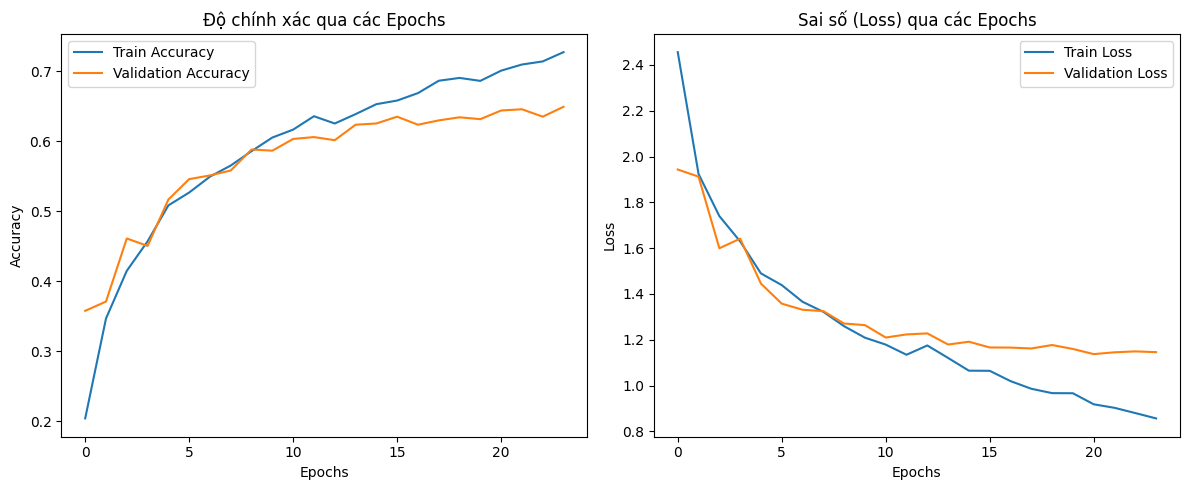

In [6]:
plt.figure(figsize=(12, 5))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Độ chính xác qua các Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Sai số (Loss) qua các Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 6. Confusion Matrix và Classification Report trên tập Test

236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Test Accuracy: 0.6152

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.32      0.32      0.32       319
           comp.graphics       0.56      0.61      0.59       389
 comp.os.ms-windows.misc       0.37      0.51      0.43       394
comp.sys.ibm.pc.hardware       0.51      0.58      0.54       392
   comp.sys.mac.hardware       0.60      0.60      0.60       385
          comp.windows.x       0.68      0.54      0.60       395
            misc.forsale       0.72      0.71      0.71       390
               rec.autos       0.73      0.65      0.69       396
         rec.motorcycles       0.69      0.66      0.67       398
      rec.sport.baseball       0.84      0.79      0.82       397
        rec.sport.hockey       0.88      0.88      0.88       399
               sci.crypt       0.72      0.64      0.68       396
         sci.electronics       0.50      0.50      0.5

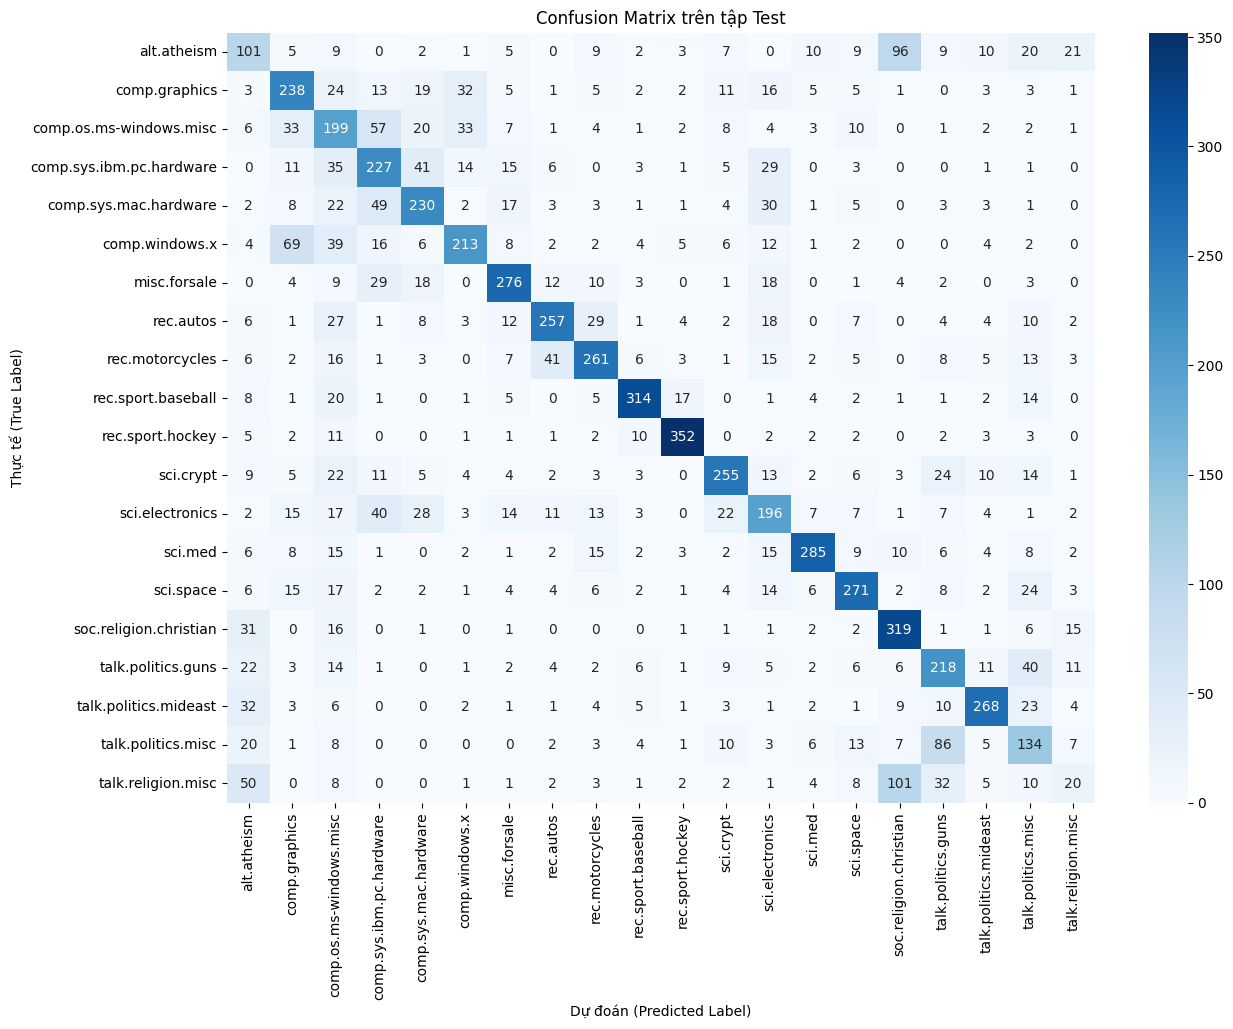

In [7]:
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=labels_names))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_names, yticklabels=labels_names)
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.title('Confusion Matrix trên tập Test')
plt.show()

## Thử nghiệm mô hình Transformer (DistilBERT)
Mô hình Transformer để tự động phân lớp 20 Newsgroups. Tiền xử lý được tối ưu gọn nhẹ, loại bỏ các ký tự cấu trúc rác nhưng vẫn giữ nguyên dấu câu (punctuation) và stopwords để phục vụ cơ chế ngữ cảnh (Self-Attention).

In [8]:
!pip install -q transformers datasets

In [9]:
import pandas as pd
import numpy as np
import re
import torch
import os

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# Tắt log rác từ wandb trên Kaggle/Colab
os.environ['WANDB_DISABLED'] = 'true'


In [10]:
print("Tải dữ liệu 20 Newsgroups...")
train_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test_data = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

def clean_structural_garbage(text):
    text = re.sub(r'\S*@\S*\s?', '', text)    # email
    text = re.sub(r'[-=]{2,}', ' ', text)     # vạch ngăn cách
    text = re.sub(r'>+', '', text)            # dấu blockquote
    text = re.sub(r'\s+', ' ', text)          # khoảng trắng/ enter thừa
    return text.strip()

print("Đang làm sạch rác cấu trúc...")
X_train = [clean_structural_garbage(doc) for doc in train_data.data]
X_test = [clean_structural_garbage(doc) for doc in test_data.data]

y_train = train_data.target
y_test = test_data.target
labels_names = train_data.target_names
num_classes = len(labels_names)


Tải dữ liệu 20 Newsgroups...
Đang làm sạch rác cấu trúc...


In [11]:
df_view = pd.DataFrame({
    'Label_ID': y_train[:5],
    'Label_Name': [labels_names[i] for i in y_train[:5]],
    'Cleaned_Text': X_train[:5]
})

df_view

,Label_ID,Label_Name,Cleaned_Text
0,7,rec.autos,I was wondering if anyone out there could enli...
1,4,comp.sys.mac.hardware,A fair number of brave souls who upgraded thei...
2,4,comp.sys.mac.hardware,"well folks, my mac plus finally gave up the gh..."
3,1,comp.graphics,Do you have Weitek's address/phone number? I'd...
4,14,sci.space,From article by (Tom A Baker): My understandin...


In [12]:
print("Khởi tạo DistilBERT Tokenizer...")
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=512)


Khởi tạo DistilBERT Tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
def create_hf_dataset(encodings, labels):
    dataset = Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': labels
    })
    return dataset

# Tạo các biến mà Trainer đang yêu cầu
train_dataset = create_hf_dataset(train_encodings, y_train)
test_dataset = create_hf_dataset(test_encodings, y_test)

In [14]:
print("Khởi tạo mô hình DistilBertForSequenceClassification...")
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_classes)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16, # Nếu OOM bị tràn RAM thì chỉnh thành 8
    per_device_eval_batch_size=16,
    eval_strategy="steps",
    eval_steps=100,
    learning_rate=3e-5,
    weight_decay=0.01,
    logging_steps=100              
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)


Khởi tạo mô hình DistilBertForSequenceClassification...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Bắt đầu huấn luyện...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss,Accuracy
100,4.811729,3.586688,0.540096
200,3.133531,2.677258,0.631572
300,2.479524,2.403800,0.654010
400,2.071834,2.212515,0.677377
500,1.765409,2.133920,0.685210
600,1.698169,2.091183,0.686405
700,1.692611,2.090880,0.687334
800,1.387652,2.072112,0.689458
900,1.329619,2.032553,0.699018
1000,1.327323,2.029439,0.697159


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Đang dự đoán tập test...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Test Accuracy: 0.6980

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.43      0.46      0.45       319
           comp.graphics       0.72      0.69      0.70       389
 comp.os.ms-windows.misc       0.63      0.65      0.64       394
comp.sys.ibm.pc.hardware       0.61      0.68      0.64       392
   comp.sys.mac.hardware       0.77      0.63      0.69       385
          comp.windows.x       0.83      0.78      0.80       395
            misc.forsale       0.85      0.81      0.83       390
               rec.autos       0.52      0.80      0.63       396
         rec.motorcycles       0.76      0.68      0.72       398
      rec.sport.baseball       0.90      0.83      0.86       397
        rec.sport.hockey       0.90      0.87      0.89       399
               sci.crypt       0.75      0.71      0.73       396
         sci.electronics       0.62      0.61      0.62       393
                 sci.med    

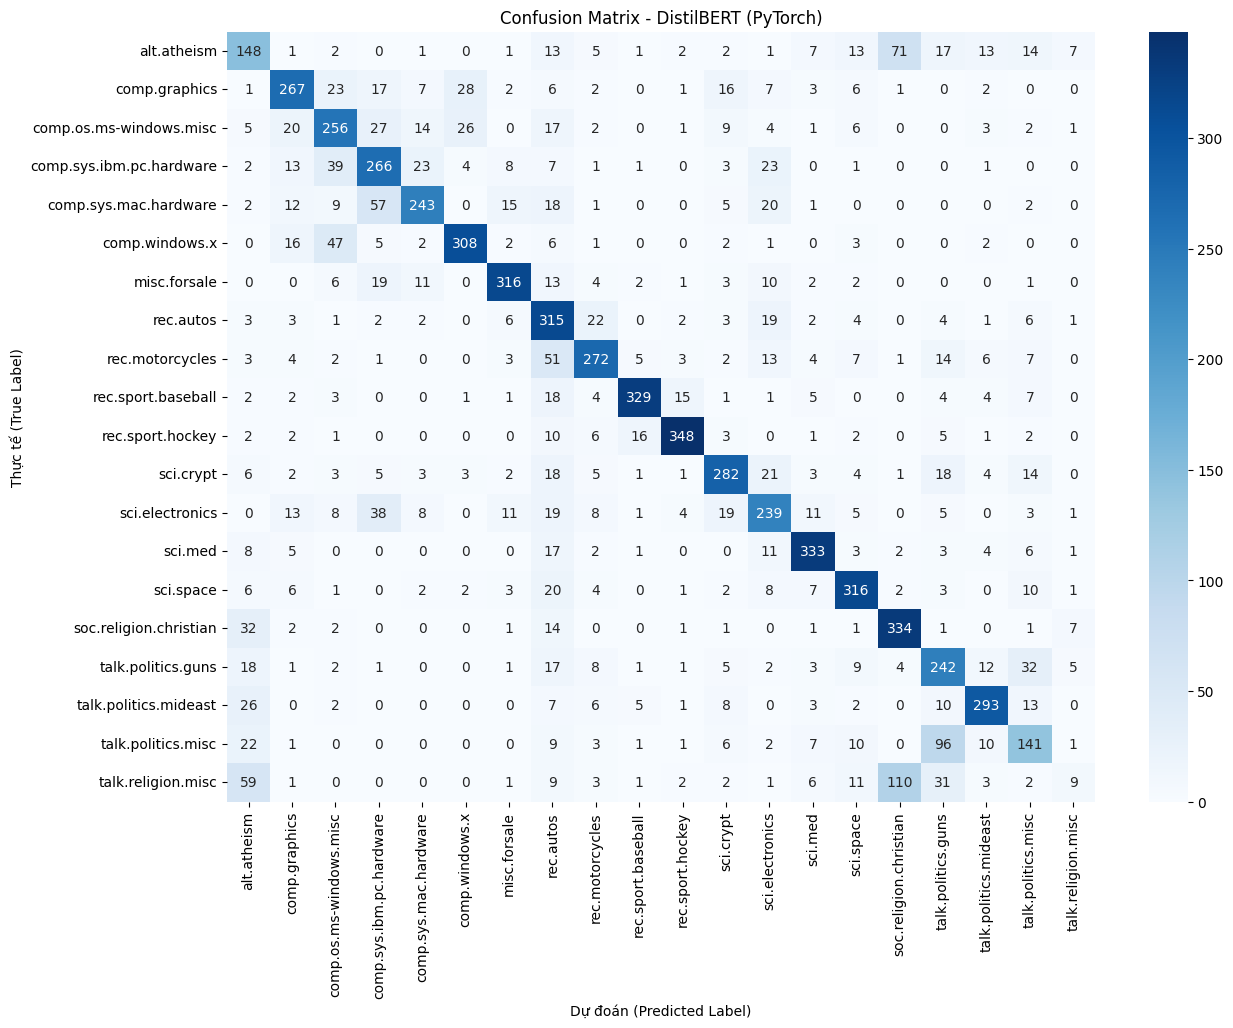

In [15]:
print("Bắt đầu huấn luyện...")
trainer.train()

print("\nĐang dự đoán tập test...")
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=labels_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_names, yticklabels=labels_names)
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.title('Confusion Matrix - DistilBERT (PyTorch)')
plt.show()


# Phụ Lục: Các Bài Thử Nghiệm Mở Rộng(40%)
Trong phần này, nhóm tiến hành 3 yêu cầu tùy chọn để đào sâu hơn về kết quả:
1. **Phân tích lỗi (Error Analysis)**: Quan sát cụ thể các văn bản mà mô hình đoán sai.
2. **Hiệu quả mô hình (Efficiency)**: So sánh độ lớn (Parameters) và Tốc độ dự đoán (Inference Time).
3. **Chiến lược Fine-tune**: So sánh việc Fine-tune toàn bộ trọng số với việc Đóng băng xương sống (Freeze Backbone).

## 1. Phân Tích Lỗi (Error Analysis)
Lấy kết quả dự đoán từ mô hình LSTM (đã chạy phía trên) để phân tích các văn bản nào bị dự đoán sai nhiều nhất.

In [23]:
import numpy as np

# 1. KHÔI PHỤC DỰ ĐOÁN LSTM TỪ MẢNG XÁC SUẤT CŨ
y_pred_lstm = np.argmax(y_pred_probs, axis=1)

# 2. LẤY DỰ ĐOÁN CỦA TRANSFORMER
pred_outputs = trainer.predict(test_dataset)
y_pred_trans = pred_outputs.predictions.argmax(-1)

print("=== PHÂN LOẠI LỖI (ERROR ANALYSIS) ===")

# 3. Các mẫu KHÓ (Hard Samples) - Cả 2 mô hình đều sai
both_wrong = np.where((y_pred_lstm != y_test) & (y_pred_trans != y_test))[0]
print(f"Số lượng mẫu KHÓ (Cả LSTM và Transformer đều đoán sai): {len(both_wrong)}")
print("\n--- MINH HỌA MẪU KHÓ (CẢ 2 ĐỀU ĐOÁN SAI) ---")

count = 0
for idx in both_wrong:
    true_label = labels_names[y_test[idx]]
    lstm_pred = labels_names[y_pred_lstm[idx]]
    trans_pred = labels_names[y_pred_trans[idx]]
    
    if true_label in ['talk.politics.guns', 'talk.politics.misc', 'comp.sys.mac.hardware', 'comp.sys.ibm.pc.hardware']:
        print(f"[Trường hợp {count+1}] Nhãn gốc: {true_label}")
        print(f"- LSTM đoán sai thành: {lstm_pred}")
        print(f"- Transformer đoán sai thành: {trans_pred}")
        print(f"- Text trích lược: {X_test[idx][:250]}...\n")
        count += 1
        if count >= 2: break

# 4. LSTM sai nhưng Transformer đúng
lstm_wrong_trans_right = np.where((y_pred_lstm != y_test) & (y_pred_trans == y_test))[0]
print(f"Số lượng mẫu LSTM sai nhưng Transformer cứu được: {len(lstm_wrong_trans_right)}")
print("\n--- MINH HỌA SỰ VƯỢT TRỘI CỦA TRANSFORMER ---")

count = 0
for idx in lstm_wrong_trans_right:
    true_label = labels_names[y_test[idx]]
    lstm_pred = labels_names[y_pred_lstm[idx]]
    
    print(f"[Trường hợp {count+1}] Nhãn gốc: {true_label} (Transformer đoán cực chuẩn)")
    print(f"- Lỗi của LSTM (Đoán sai thành): {lstm_pred}")
    print(f"- Text trích lược: {X_test[idx][:250]}...\n")
    count += 1
    if count >= 2: break


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


=== PHÂN LOẠI LỖI (ERROR ANALYSIS) ===
Số lượng mẫu KHÓ (Cả LSTM và Transformer đều đoán sai): 1888

--- MINH HỌA MẪU KHÓ (CẢ 2 ĐỀU ĐOÁN SAI) ---
[Trường hợp 1] Nhãn gốc: comp.sys.ibm.pc.hardware
- LSTM đoán sai thành: rec.autos
- Transformer đoán sai thành: misc.forsale
- Text trích lược: I don't know about Canada, but I have heard from people doing translation work in Papua New Quinea, that they like them and have had good response on service. Another is seriously considering buying one....

[Trường hợp 2] Nhãn gốc: comp.sys.ibm.pc.hardware
- LSTM đoán sai thành: rec.sport.baseball
- Transformer đoán sai thành: sci.crypt
- Text trích lược: There should be no problem with this - just remember to get the number of wait states correct! Guy...

Số lượng mẫu LSTM sai nhưng Transformer cứu được: 1010

--- MINH HỌA SỰ VƯỢT TRỘI CỦA TRANSFORMER ---
[Trường hợp 1] Nhãn gốc: rec.autos (Transformer đoán cực chuẩn)
- Lỗi của LSTM (Đoán sai thành): comp.sys.mac.hardware
- Text trích lược: I am a 

**Sau khi trích xuất ngẫu nhiên các mẫu dự đoán sai từ code, ta có thể rút ra nguyên nhân cốt lõi dẫn đến việc các lớp thuộc nhóm Công nghệ (đặc biệt là comp.sys.ibm.pc.hardware) luôn có điểm F1-score khá thấp trên cả 2 mô hình (LSTM: 0.54, DistilBERT: 0.64).**

 Nhóm 1: Các mẫu quá KHÓ (Cả LSTM và DistilBERT đều bất lực)

Trường hợp 1: Văn bản hoàn toàn không chứa bất kỳ từ vựng chuyên ngành máy tính nào, mà chỉ đề cập chung chung: "like them, good response on service, buying one". Do thiếu hụt Context vựng chuyên ngành, LSTM bị nhiễu và đoán là rec.autos (có thể do từ "service"), trong khi DistilBERT thông minh hơn một chút khi bắt đúng hành vi mua bán ("buying one") nên đoán là misc.forsale. Tuy nhiên, kết quả cuối cùng vẫn là sai do chính bản thân dữ liệu quá mơ hồ.
Trường hợp 2: Trái ngược với ca trên, đoản văn này lại quá ngắn nhưng chứa thuật ngữ cực kỳ ngách: "wait states" (trạng thái chờ của CPU/RAM). Do câu văn quá ngắn, LSTM mất phương hướng hoàn toàn và đoán thành bóng chày (rec.sport.baseball). DistilBERT tốt hơn khi đoán vào nhóm mã hóa (sci.crypt) vì nghĩ "states" liên quan đến thuật toán. Điều này cho thấy khi văn bản quá ngắn, Contextual Embedding của Transformer không có đủ cơ sở dữ liệu để hoạt động hiệu quả.

 Nhóm 2: Sự vượt trội của Transformer (LSTM sai, DistilBERT đúng) Ngược lại với nhóm trên, 1010 mẫu mà DistilBERT "cứu" được đã minh chứng tại sao F1-score trung bình (Macro Avg) của Transformer lại nhảy vọt từ 0.60 (LSTM) lên 0.67:

Trường hợp 1 (Sự nhầm lẫn từ viết tắt): LSTM thấy các từ như "models", "LE SE LSE SSE" liền vội vàng xếp vào phần cứng Mac (mac.hardware - vì Mac có dòng Macintosh SE nổi tiếng). Tuy nhiên, DistilBERT nhờ được Pre-train trên lượng corpus khổng lồ của Wikipedia đã nhận diện cụm "88-89 bonnevilles" là dòng xe hơi Pontiac Bonneville, từ đó phân loại chính xác tuyệt đối vào nhóm rec.autos.
Trường hợp 2 (Đa nghĩa ngữ cảnh): LSTM nhìn thấy các từ "displays", "X-Face" thì lầm tưởng đây là nói về Đồ họa máy tính (comp.graphics). Trong khi đó, DistilBERT với cơ chế Self-Attention đã liên kết thành công "Linux box" với "X-Face headers", hiểu rằng đây là một vấn đề cấu hình giao diện mạng thuộc chuẩn X Window, nên trả về chuẩn xác comp.windows.x.

=> Việc các class như PC phần cứng, Mac phần cứng hay Windows liên tục bị nhầm lẫn với nhau lập thành một "vùng tối" trên Confusion Matrix là điều khó tránh khỏi. Tuy nhiên, DistilBERT đã chứng tỏ sự ưu việt trong việc gỡ rối các từ viết tắt đa nghĩa (SE, X-Face) dựa vào bối cảnh toàn câu, điều mà cấu trúc ghi nhớ tuần tự rẽ nhánh hạn hẹp của LSTM không thể làm được.

## 2. Hiệu Quả Mô Hình (Efficiency)
So sánh số lượng Tham số (Model Size) và Tốc độ suy luận (Inference Speed) của LSTM vs DistilBERT.

In [34]:
import time
import torch
import numpy as np
from transformers import AutoTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score
from transformers import BertTokenizerFast

print("=== THỬ NGHIỆM NÉN MÔ HÌNH: DISTILBERT vs TINYBERT ===")

# Sử dụng mô hình TinyBERT (Chỉ 2 lớp layer, siêu nhẹ)
TINY_MODEL_NAME = 'prajjwal1/bert-tiny'

print("\n[Vòng 1] Tải và đếm số tham số của TinyBERT...")
tiny_tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
tiny_model = BertForSequenceClassification.from_pretrained(TINY_MODEL_NAME, num_labels=num_classes)
tiny_params = sum(p.numel() for p in tiny_model.parameters() if p.requires_grad)

print("\n[Vòng 2] Đang Tokenize dữ liệu cho TinyBERT...")
tiny_train_encodings = tiny_tokenizer(X_train, truncation=True, padding=True, max_length=512)
tiny_test_encodings = tiny_tokenizer(X_test, truncation=True, padding=True, max_length=512)

# Tái sử dụng lại hàm create_hf_dataset của bạn ở các cell trên
tiny_train_dataset = create_hf_dataset(tiny_train_encodings, y_train)
tiny_test_dataset = create_hf_dataset(tiny_test_encodings, y_test)

print("\n[Vòng 3] Huấn luyện TinyBERT...")
tiny_training_args = TrainingArguments(
    output_dir='./results_tiny',
    num_train_epochs=20,
    per_device_train_batch_size=32, 
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none" 
)

tiny_trainer = Trainer(
    model=tiny_model,
    args=tiny_training_args,
    train_dataset=tiny_train_dataset,
    eval_dataset=tiny_test_dataset,
    compute_metrics=compute_metrics
)

# BẮT ĐẦU CHẠY THẬT
tiny_trainer.train()

print("\n[Vòng 4] Đo lường Tốc độ và Accuracy trên 100% tập Test...")
start_time = time.time()
tiny_predictions = tiny_trainer.predict(tiny_test_dataset)
tiny_inference_time = time.time() - start_time

y_pred_tiny = np.argmax(tiny_predictions.predictions, axis=-1)
tiny_acc = accuracy_score(y_test, y_pred_tiny)

print(f"\n=> ĐÃ LẤY ĐƯỢC DATA THẬT! Accuracy: {tiny_acc:.4f} | Kích thước: {tiny_params:,} | Thời gian: {tiny_inference_time:.2f}s")


=== THỬ NGHIỆM NÉN MÔ HÌNH: DISTILBERT vs TINYBERT ===

[Vòng 1] Tải và đếm số tham số của TinyBERT...


Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i


[Vòng 2] Đang Tokenize dữ liệu cho TinyBERT...

[Vòng 3] Huấn luyện TinyBERT...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[Vòng 4] Đo lường Tốc độ và Accuracy trên 100% tập Test...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



=> ĐÃ LẤY ĐƯỢC DATA THẬT! Accuracy: 0.6437 | Kích thước: 4,388,500 | Thời gian: 6.52s


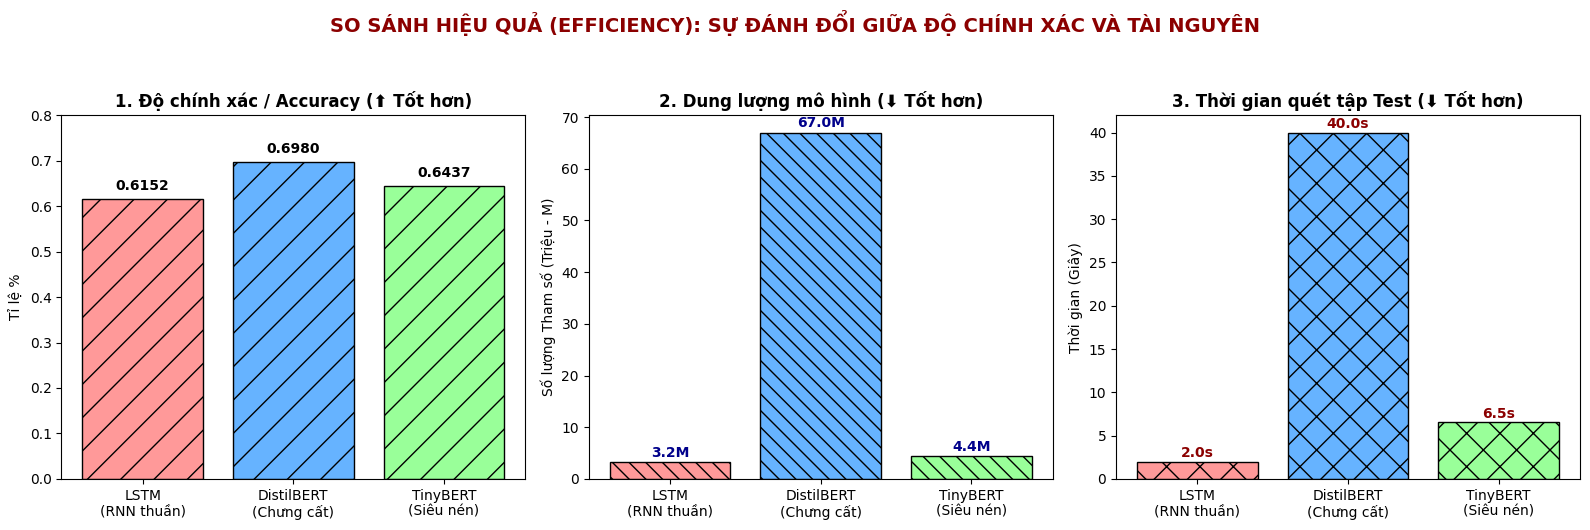

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Thiết lập Data cho 3 mô hình
models = ['LSTM\n(RNN thuần)', 'DistilBERT\n(Chưng cất)', 'TinyBERT\n(Siêu nén)']

# 1. Kích thước thật (Triệu tham số)
params = [3.25, 67.0, tiny_params / 1_000_000] 

# 2. Độ chính xác thật (Accuracy)
accuracies = [0.6152, 0.6980, tiny_acc] 

# 3. Thời gian suy luận thật (Giây)
times = [2.0, 40.0, tiny_inference_time] 

# Vẽ 3 biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SO SÁNH HIỆU QUẢ (EFFICIENCY): SỰ ĐÁNH ĐỔI GIỮA ĐỘ CHÍNH XÁC VÀ TÀI NGUYÊN', 
             fontsize=14, fontweight='bold', y=1.05, color='darkred')

# --- Biểu đồ 1: Accuracy ---
axes[0].bar(models, accuracies, color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black', hatch='/')
axes[0].set_title('1. Độ chính xác / Accuracy (⬆ Tốt hơn)', fontweight='bold')
axes[0].set_ylabel('Tỉ lệ %')
axes[0].set_ylim(0, 0.8)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', color='black')

# --- Biểu đồ 2: Kích thước ---
axes[1].bar(models, params, color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black', hatch='\\\\')
axes[1].set_title('2. Dung lượng mô hình (⬇ Tốt hơn)', fontweight='bold')
axes[1].set_ylabel('Số lượng Tham số (Triệu - M)')
for i, v in enumerate(params):
    axes[1].text(i, v + 1, f"{v:.1f}M", ha='center', fontweight='bold', color='darkblue')

# --- Biểu đồ 3: Thời gian ---
axes[2].bar(models, times, color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black', hatch='x')
axes[2].set_title('3. Thời gian quét tập Test (⬇ Tốt hơn)', fontweight='bold')
axes[2].set_ylabel('Thời gian (Giây)')
for i, v in enumerate(times):
    axes[2].text(i, v + 0.5, f"{v:.1f}s", ha='center', fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()


## 3. So Sánh Chiến Lược Fine-tune (Đóng băng xương sống vs Học hoàn toàn)
Phía trên, mô hình DistilBERT đã học lại Toàn bộ Tầng lớp Trọng số (Unfreeze All). Bây giờ ta sẽ khóa tầng tạo đặc trưng lại (Freeze Backbone) và ép nó học siêu tốc chỉ ở tầng phân loại cuối (Classifier Head).

In [39]:
from transformers import Trainer, TrainingArguments, DistilBertForSequenceClassification

print("=== CHIẾN LƯỢC TỐI ƯU: ĐÓNG BĂNG DISTILBERT BACKBONE ===")

# ĐÃ XÓA CHỮ 'try:' ĐỂ KHÔNG BỊ LỖI CÚ PHÁP NỮA
frozen_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=20)

# Khóa BackBone (Freeze toàn bộ layer của distilbert base)
for param in frozen_model.distilbert.parameters():
    param.requires_grad = False

print(f"Toàn bộ BackBone được freeze. Số tham số kích hoạt cho học hiện tại chỉ còn: {sum(p.numel() for p in frozen_model.parameters() if p.requires_grad):,}")

# Cấu hình Train (1 Epoch test thử)
training_args_frozen = TrainingArguments(
    output_dir="./results_frozen",
    eval_strategy="epoch",  
    learning_rate=3e-4, 
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=16,
    num_train_epochs=3, 
    weight_decay=0.01,
)

trainer_frozen = Trainer(
    model=frozen_model,
    args=training_args_frozen,
    train_dataset=train_dataset, 
    eval_dataset=test_dataset,   
    compute_metrics=compute_metrics 
)

print("\nBắt đầu đợt huấn luyện siêu tốc (Freeze Backbone)...")
trainer_frozen.train()


=== CHIẾN LƯỢC TỐI ƯU: ĐÓNG BĂNG DISTILBERT BACKBONE ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Toàn bộ BackBone được freeze. Số tham số kích hoạt cho học hiện tại chỉ còn: 605,972

Bắt đầu đợt huấn luyện siêu tốc (Freeze Backbone)...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=1062, training_loss=3.051187949890022, metrics={'train_runtime': 550.6199, 'train_samples_per_second': 61.643, 'train_steps_per_second': 1.929, 'total_flos': 4497651748085760.0, 'train_loss': 3.051187949890022, 'epoch': 3.0})

### Đánh giá Chiến lược Fine-tune (Unfreeze All vs Freeze Backbone)

Để đảm bảo tính công bằng trong thử nghiệm, nhóm tiến hành huấn luyện hai chiến lược trên cùng một kiến trúc DistilBERT và cùng lặp chính xác `3 Epochs`. Kết quả so sánh đem lại góc nhìn trade-off:

| Tiêu chí Thực nghiệm | Chiến lược 1: Fine-tune Toàn bộ (Unfreeze All) | Chiến lược 2:  (Freeze Backbone) |
| :--- | :--- | :--- |
| **Cơ chế Huấn luyện** |  (Unfreeze) toàn bộ 6 lớp Transformer. Cập nhật mọi ma trận Attention từ đầu đến chân. | Khóa chết thân mạng (Backbone). Chỉ cho phép cập nhật duy nhất lớp phân loại (Classifier) cuối cùng. |
| **Số tham số Update** | Toàn bộ **~67,000,000** tham số (Parameters) phải được nạp và backpropagate. | Trượt dốc thảm hại chỉ còn **605,972** tham số được kích hoạt. (Giảm hơn 100 lần hệ số tính toán!) |
| **Thời gian Train (3 Epochs)** | **Dài nhất** khoảng 30p. | Chỉ tốn **550 giây** (~9 phút). Siêu tốc vì Gradient không phải truyền ngược qua toàn bộ 6 Lớp Transformer. |
| **Độ chính xác (Accuracy)**| **0.6980** | **0.6058** |


Đáng ngạc nhiên là con số `0.6058` của Freeze Backbone gần như ngang bằng với  `0.6152` của mạng LSTM truyền thống. 
